# Simplified Code Samples

This file contains code to perform some fundamental tasks for climate data analysis. I have designed it to be simpler and more bare-bones than the examples in the full tutorial, accomplishing the necessary tasks in as few lines of code as possible. This means the resulting plots may not be as beautiful, as elegantly coded, or as fully customizable, but the code should be easier to understand, modify, and debug.

## Import Packages

In [1]:
import xarray as xr
import pathlib
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings

In [3]:
# Ignore a common unnecessary warning
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in create_collection",
    category=RuntimeWarning
)

## Load Dataset from Server

```{admonition} Connect to server!
Remember that you need to connect to the server before running this code!
```

In [4]:
## Specify filepath to CMIP server on your computer

# For Mac
server_path = pathlib.Path("/Volumes/cmip6")

# For Windows
# server_path = pathlib.Path("Z:")

# This might be different for you, check for your specific computer

In [6]:
# Path to the data
path_on_server = pathlib.Path("data/cmip6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Omon/tos/gr/1")
path = server_path / path_on_server

# Get list of files
files = list(path.glob("*.nc"))

# Open dataset using xarray
ds = xr.open_mfdataset(files)

/Users/aschefler/opt/anaconda3/envs/tutorial_env/lib/python3.11/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'tos' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [7]:
# Extract just the variable of interest from the dataset
data = ds.tos

## Take a first look at the data

In [8]:
data

<xarray.DataArray 'tos' (time: 1980, lat: 180, lon: 360)> Size: 513MB
dask.array<open_dataset-tos, shape=(1980, 180, 360), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16kB 1850-01-15 13:00:00.000007 ... 2014-12-15 12:...
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

In [9]:
# What are some typical values in this dataset?

data.isel(time=0).sel(lat=10, method='nearest').values

array([      nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan, 26.382313, 26.578289, 26.527422,
       26.42661 , 26.404663, 26.433376, 26.45631 , 26.477928, 26.520796,
       26.573238, 26.645615, 26.745466, 26.861673, 26.984446, 27.112825,
       27.25479 , 27.422739, 27.65096 , 27.869148, 28.072744, 28.28039 ,
       28.503195, 28.712662, 28.844553, 28.858627,       nan,       nan,
             nan,       nan, 27.575289, 27.646214, 

### "Loading" the dataset

Xarray automatically opens the dataset in chunks, and doesn’t actually load the values until you need them. If you know you will need all the data in the dataset, you may want to load it at the start. But if it’s a big dataset, and you know you will be subsetting or taking an average over one dimension, you may want to wait so you don’t load more than you need. For more information on chunking and parallel computing in xarray, see the following page: https://docs.xarray.dev/en/stable/user-guide/dask.html

In [15]:
# *** OPTIONAL ***

data.load()

# Note: If you don't load now, you will want to run .load() or .compute() later, after you have taken your mean/subset

<xarray.DataArray 'tos' (time: 1980, lat: 180, lon: 360)> Size: 513MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.8100313, -1.8100518, -1.8100647, ..., -1.8099182,
         -1.8099555, -1.809998 ],
        [-1.8050151, -1.8050075, -1.8049895, ..., -1.8049663,
         -1.804992 , -1.8050089],
        [-1.8005803, -1.8005588, -1.8005334, ..., -1.8006624,
         -1.8006387, -1.8006104]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [-1.7614878, -1.7614846, -1.7614725, ..., -1.7614315,
         -1.7614512, -1.7614762],
        [-1.7567462, -1.756719 , -1.7566823, ..., -1.7567668,
         -1.7567681, -1.7567618],
        [-1.752961 , -1.7529289, -1.7528929, ..., -1.7530628,
         -1.7530322, -1.7529978]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.7728076, -1.7727966, -1.7727754, ..., -1.7727689,
         -1.7727833, -1.7728027],
        [-1.7678865, -1.7678522, -1.767808 , ..., -1.7679257,
         -1.7679212, -1.7679087],
        [-1.7640058, -1.7639699, -1.7639298, ..., -1.7641156,
         -1.7640821, -1.7640452]]], shape=(1980, 180, 360), dtype=float32)
Coordinates:
  * time     (time) object 16kB 1850-01-15 13:00:00.000007 ... 2014-12-15 12:...
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

## Create a spatial plot

For more information on using the mapping package Cartopy, read the documentation here: https://cartopy.readthedocs.io/stable/matplotlib/intro.html

In [16]:
# Average over the "time" dimension:
data_spatial = data.mean('time').compute()

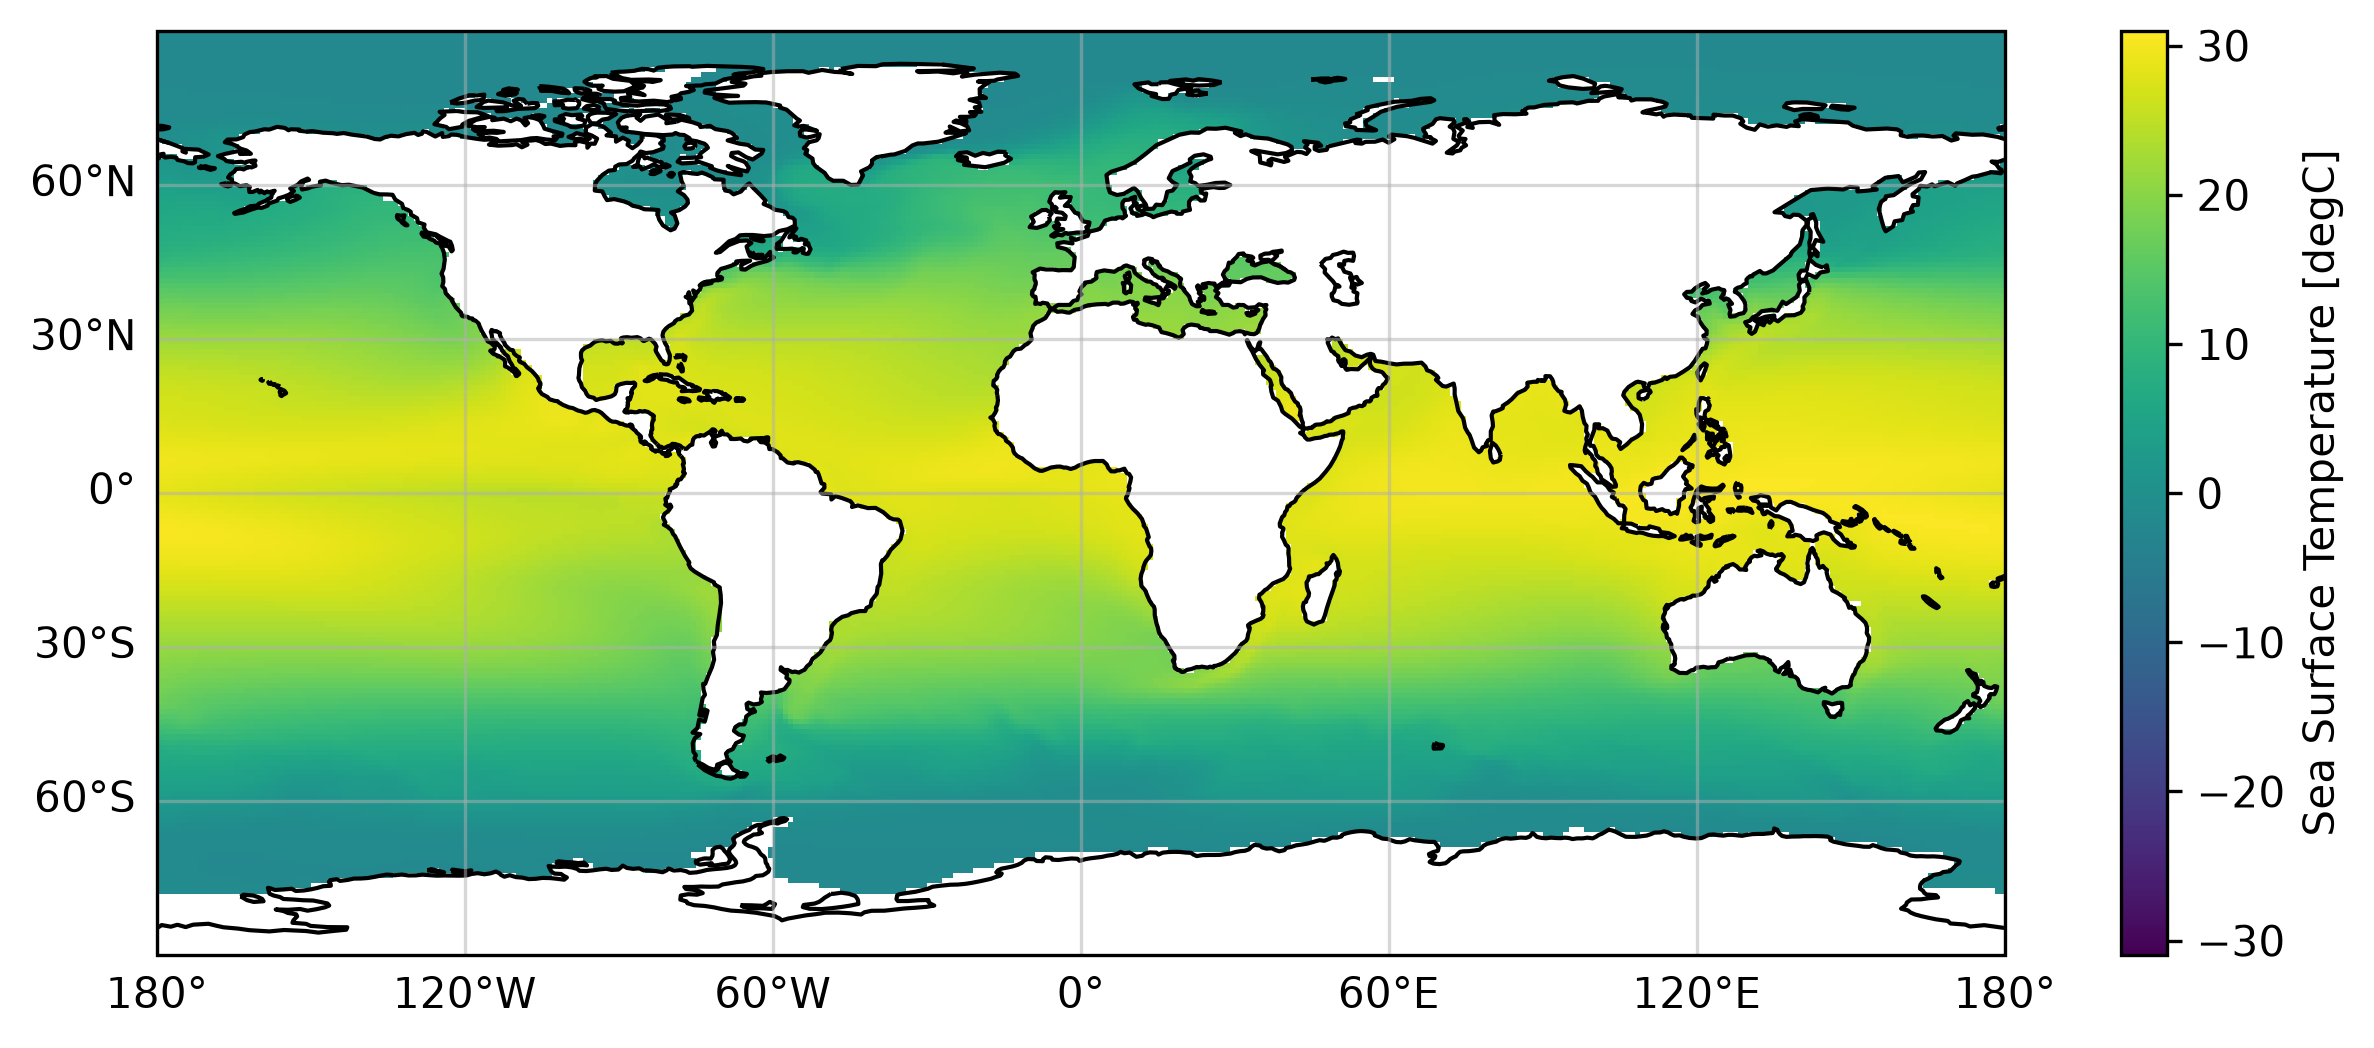

In [128]:
# Blank canvas to plot on
fig = plt.figure(figsize=(10,4), dpi=300) # dpi controls the image resolution

# Set up plot axis as a geographic map
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

# Might be helpful to set min and max values for the plot. For global SST, try vmin=0, vmax=30.
vmin = None
vmax = None

# Plot the data
data_spatial.plot(ax=ax, vmin=vmin, vmax=vmax, cmap='viridis')
# cmap is the colormap. More colormap options here: https://matplotlib.org/stable/users/explain/colors/colormaps.html
# Or can use a colormap from the cmocean package: https://matplotlib.org/cmocean/

# Add lat/lon gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), alpha=0.5) # alpha is a useful parameter - controls transparency/opacity
gl.bottom_labels = True
gl.left_labels = True

# OPTIONAL: save the figure on your computer
# fig.savefig("FILE_NAME.png")

plt.show()

### Creating the plot more manually, instead of automatically with Xarray. Allows for more customization

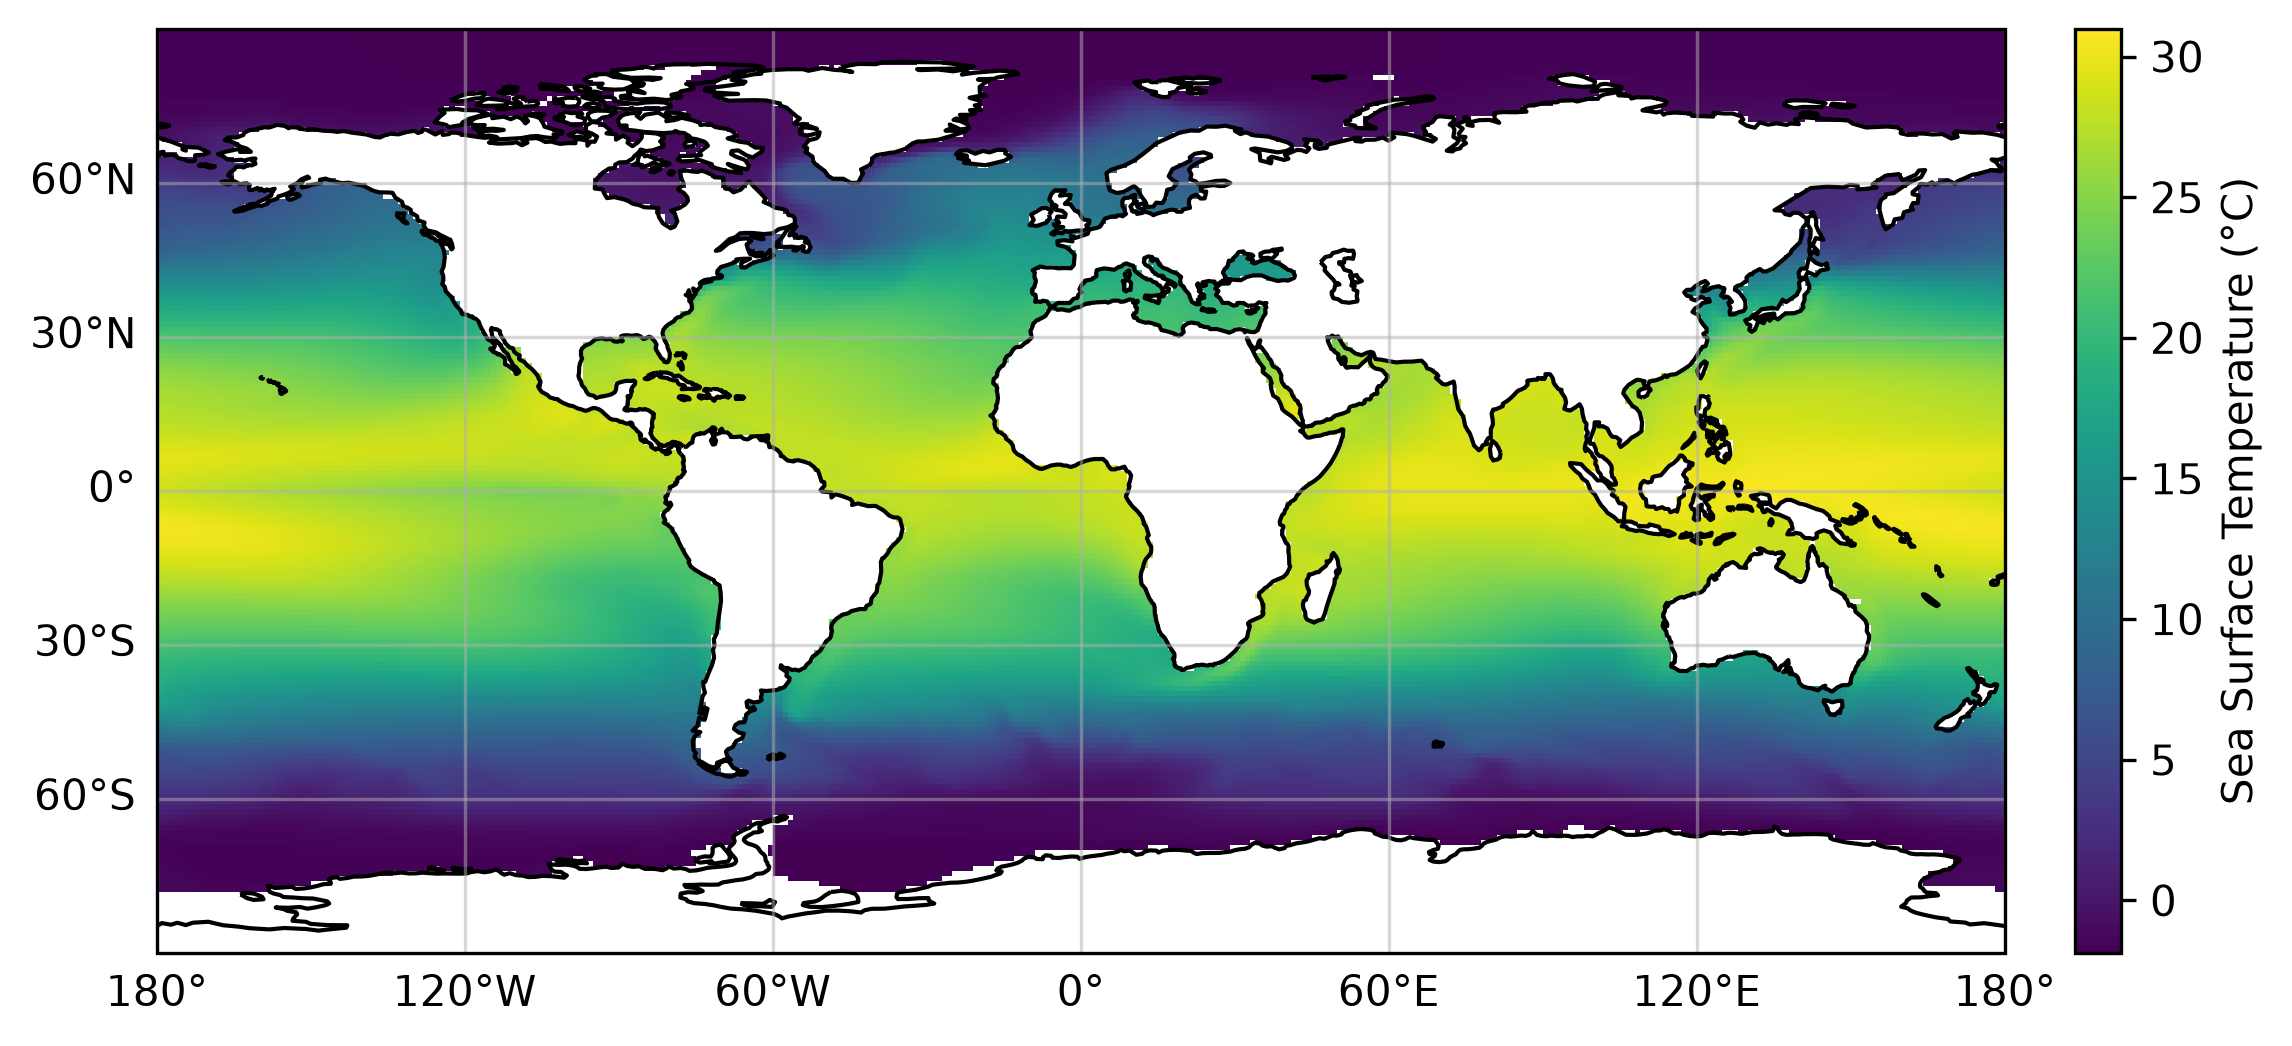

In [135]:
# Blank canvas to plot on
fig = plt.figure(figsize=(10,4), dpi=300) # dpi controls the image resolution

# Set up plot axis as a geographic map
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

# Might be helpful to set min and max values for the plot. For global SST, try vmin=0, vmax=30.
vmin = None
vmax = None

# Plot the data
pc = ax.pcolormesh(data_spatial.lon, data_spatial.lat, data_spatial, vmin=vmin, vmax=vmax, cmap='viridis')

# Add a colorbar
cbar = plt.colorbar(pc, label='Sea Surface Temperature (°C)', pad=0.03)

# Add lat/lon gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), alpha=0.5) # alpha is a useful parameter - controls transparency/opacity
gl.bottom_labels = True
gl.left_labels = True

# OPTIONAL: save the figure on your computer
# fig.savefig("FILE_NAME.png")

plt.show()

### Contour Plot

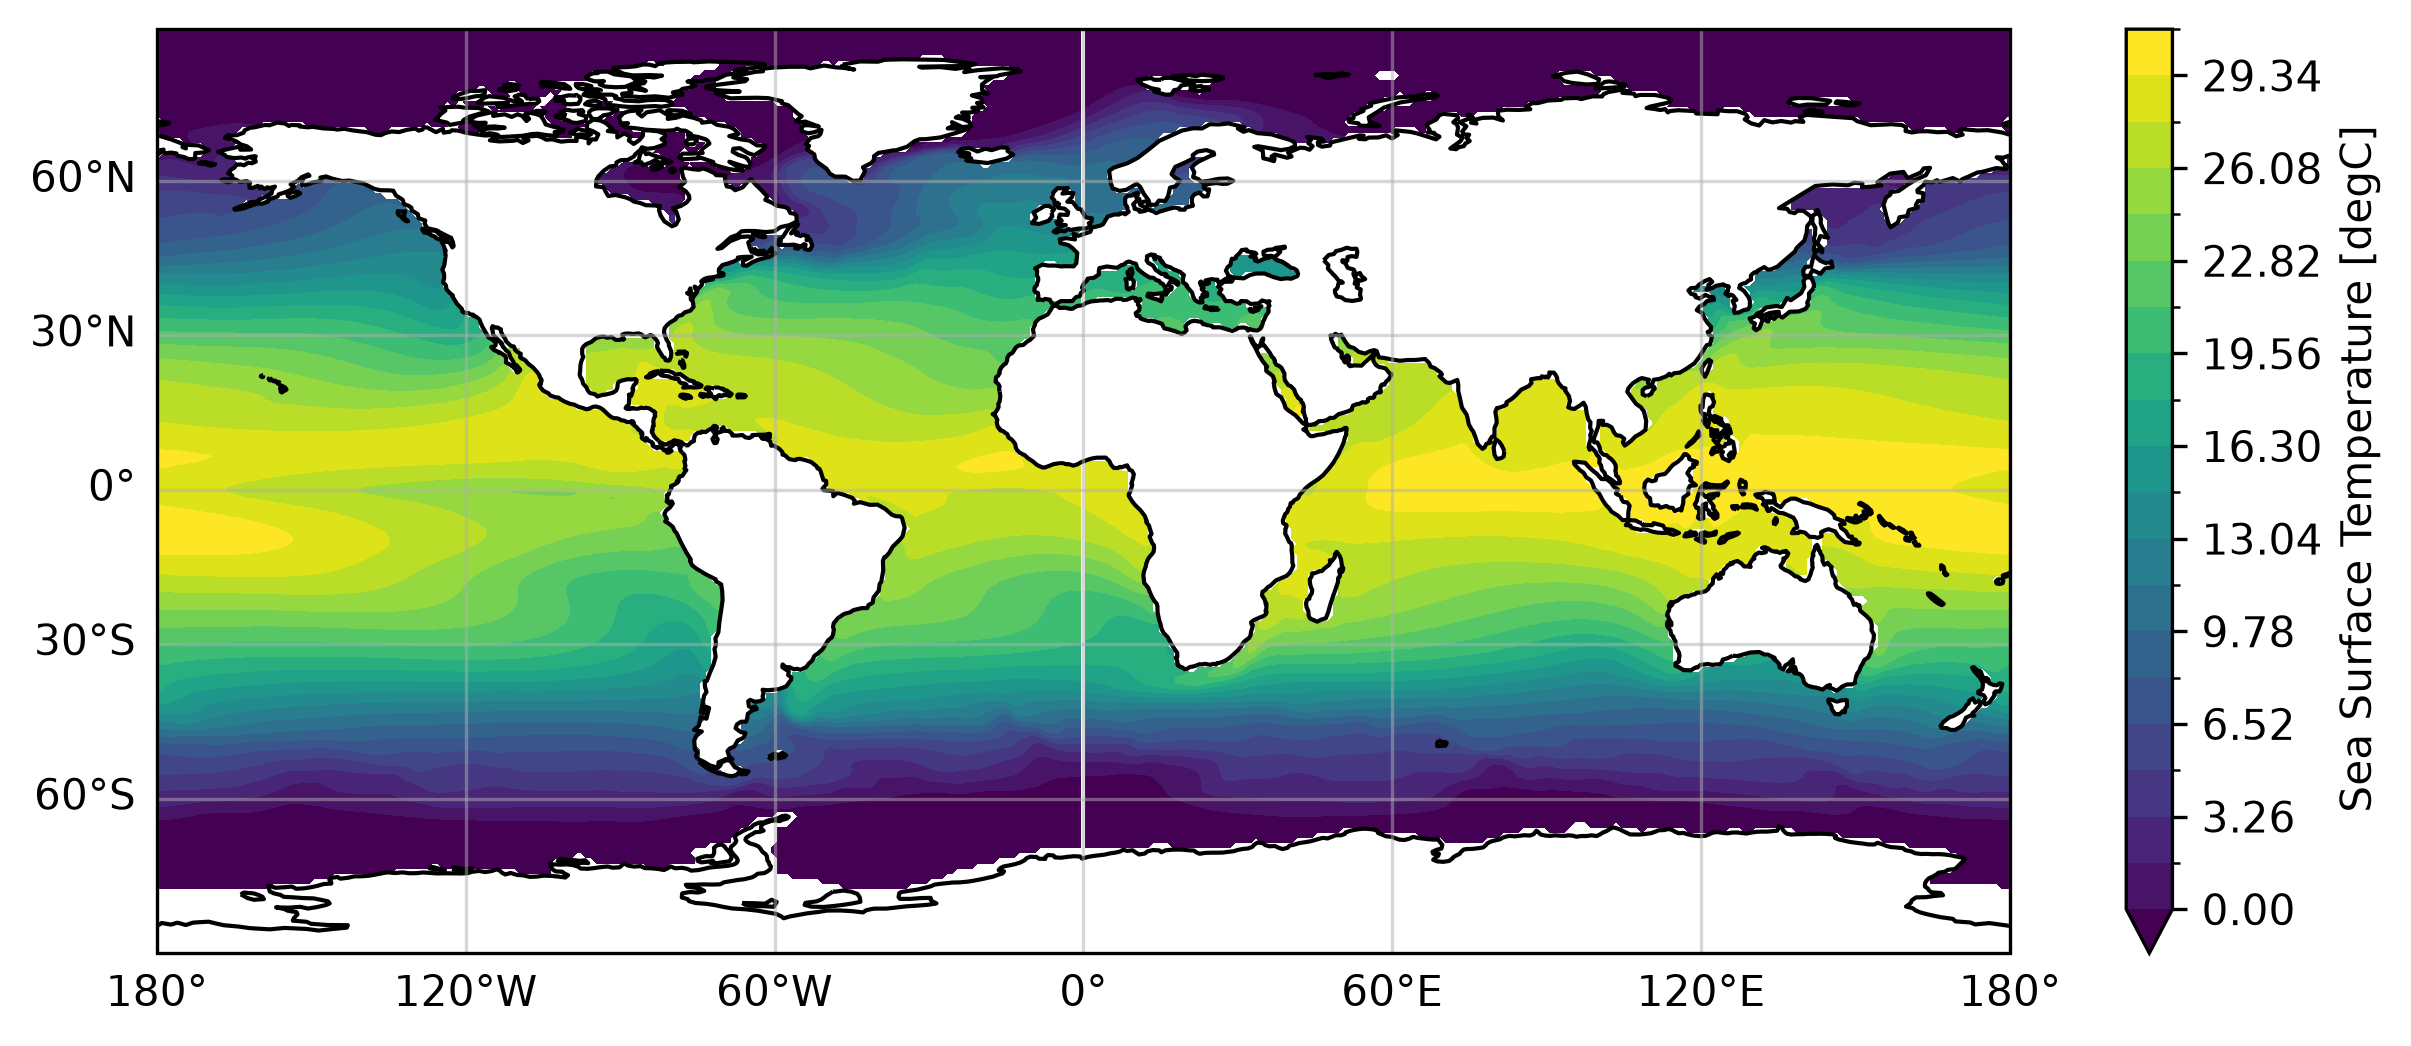

In [108]:
# Blank canvas to plot on
fig = plt.figure(figsize=(10,4), dpi=300) # dpi controls the image resolution

# Set up plot axis as a geographic map
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

# Plot the data
data_spatial.plot.contourf(ax=ax, levels=20, cmap='viridis', vmin=0)

# Add lat/lon gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), alpha=0.5) # alpha is a useful parameter - controls transparency/opacity
gl.bottom_labels = True
gl.left_labels = True

# OPTIONAL: save the figure on your computer
# fig.savefig("FILE_NAME.png")

plt.show()

## Select a subset of a dataset

In [109]:
# Select a geographic region. As an example, I'll look at the tropical Indian Ocean
lat_bounds = [-30, 30]
lon_bounds = [30, 120]

data_subset = data.sel(lon=slice(lon_bounds[0], lon_bounds[1]), lat=slice(lat_bounds[0], lat_bounds[1]))

### Visualize your selection

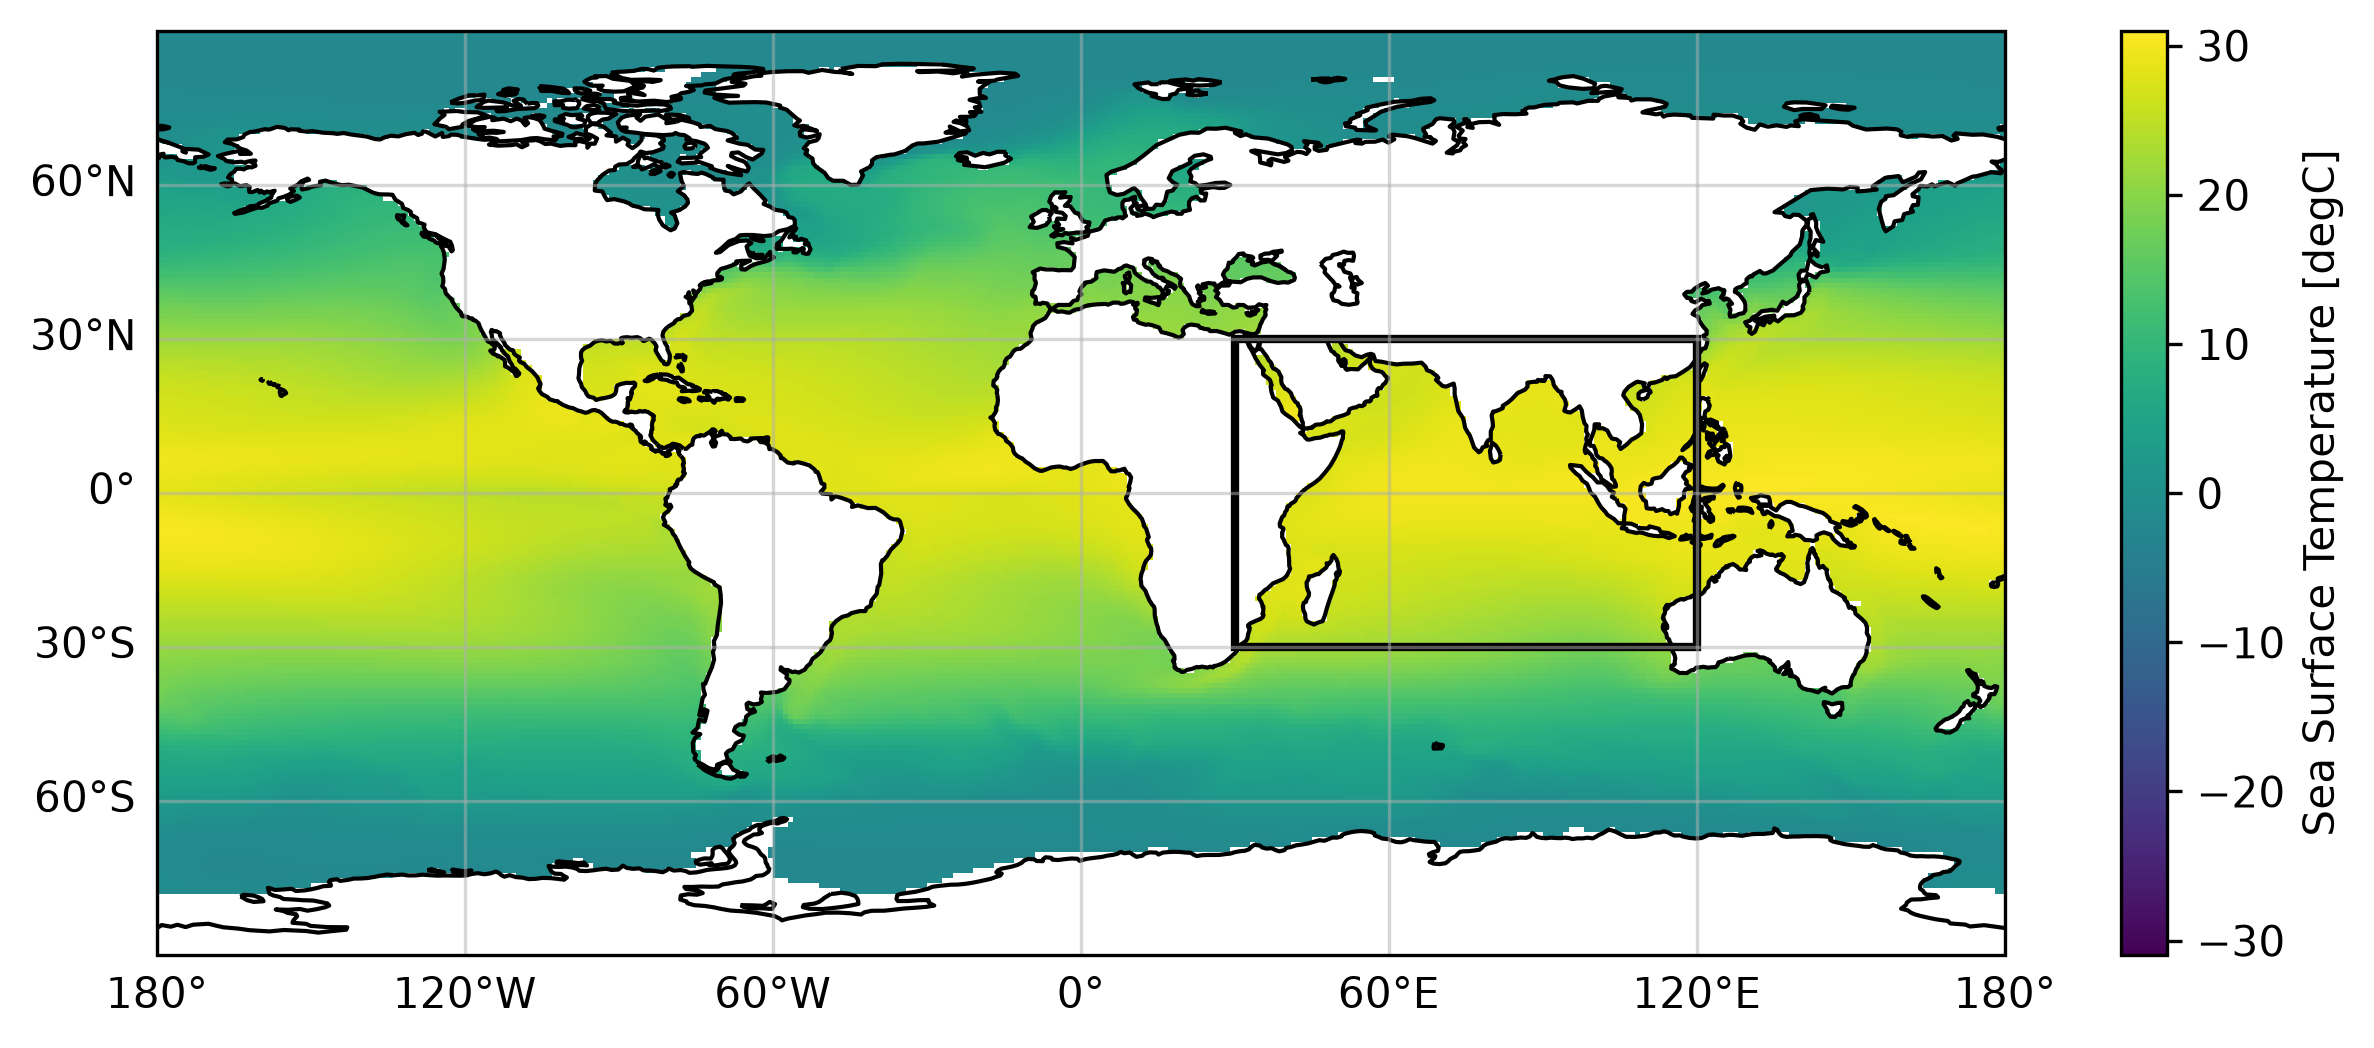

In [110]:
# Showing region with a box

# Blank canvas to plot on
fig = plt.figure(figsize=(10,4), dpi=300) # dpi controls the image resolution

# Set up plot axis as a geographic map
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

# Might be helpful to set min and max values for the plot. For global SST, try vmin=0, vmax=30.
vmin = None
vmax = None

# Plot the data
data_spatial.plot(ax=ax, vmin=vmin, vmax=vmax, cmap='viridis')

# Add lat/lon gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), alpha=0.5) # alpha is a useful parameter - controls transparency/opacity
gl.bottom_labels = True
gl.left_labels = True

# Plot a box showing your spatial region of interest
ax.add_patch(
    mpatches.Rectangle(
        xy=[lon_bounds[0], lat_bounds[0]],
        height=lat_bounds[1] - lat_bounds[0],
        width=lon_bounds[1] - lon_bounds[0],
        transform=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=2,
    )
)

# OPTIONAL: save the figure on your computer
# fig.savefig("FILE_NAME.png")

plt.show()

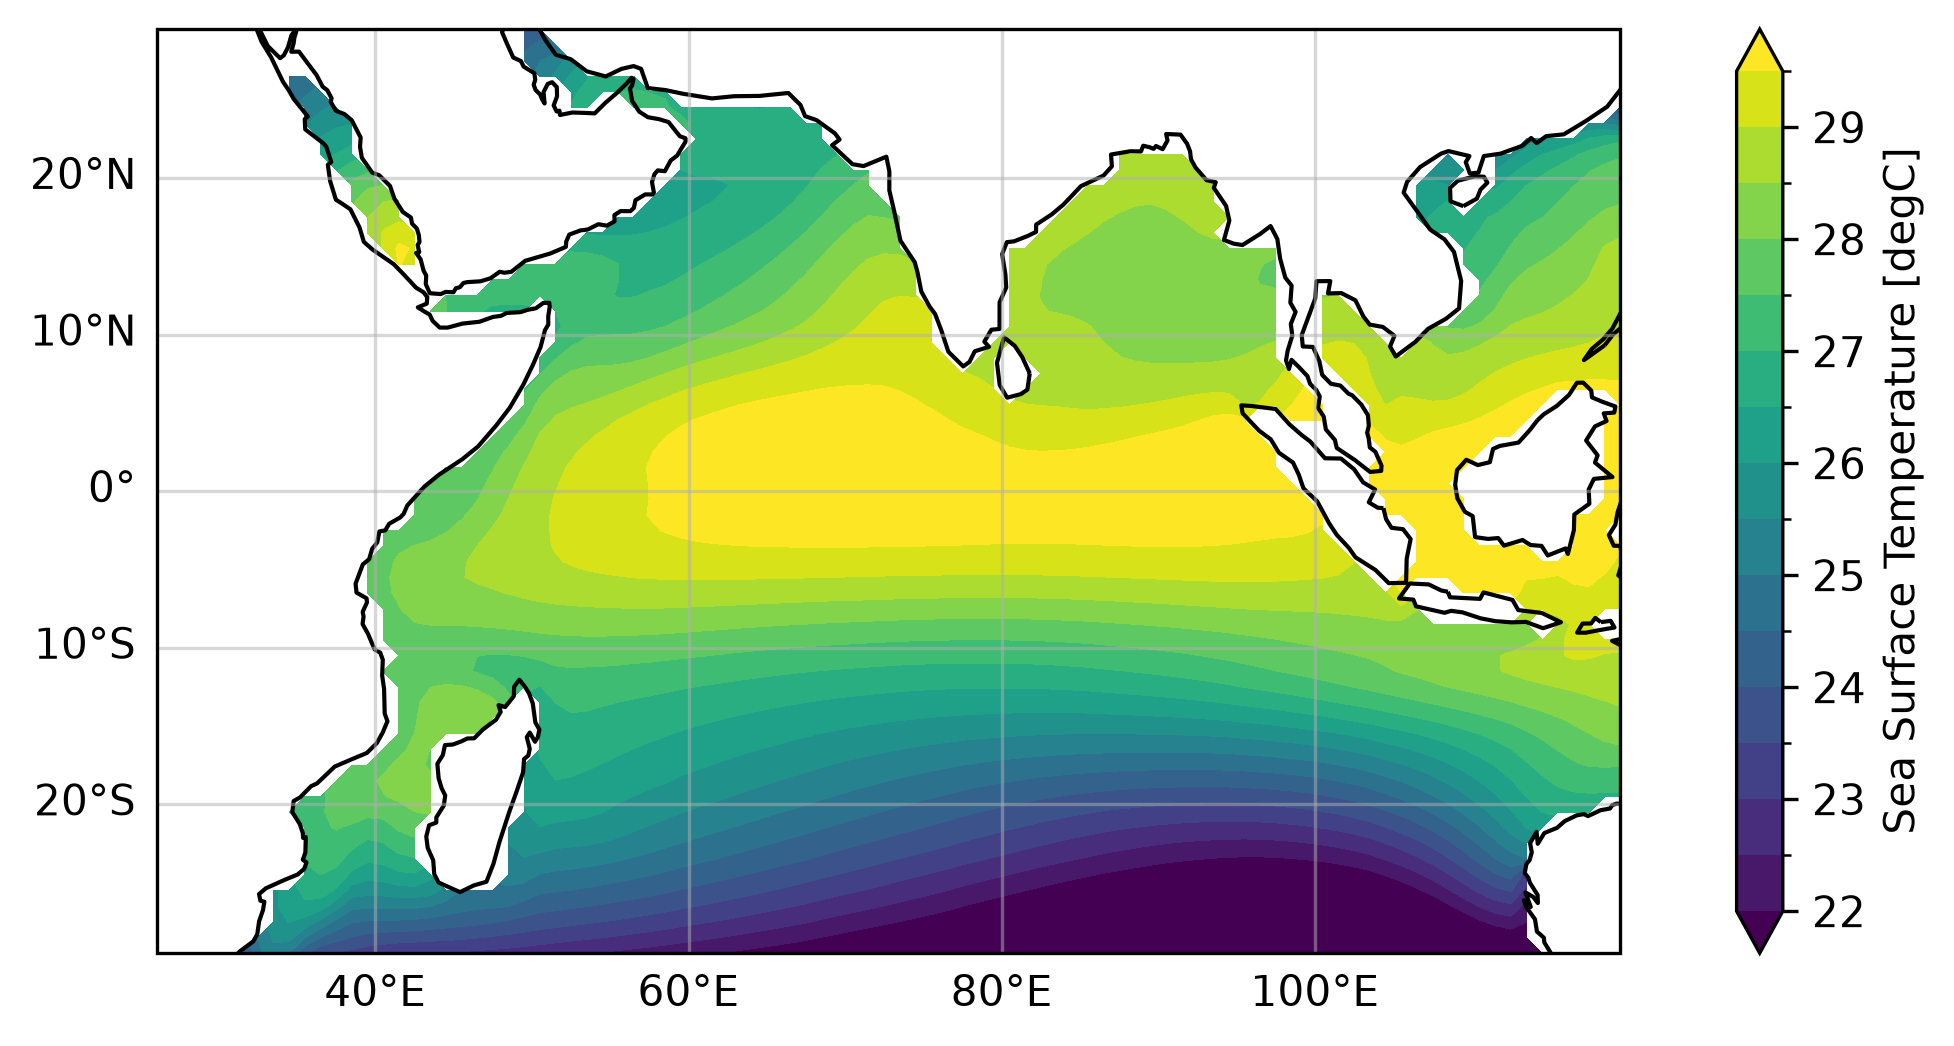

In [111]:
# Zooming in on just that region

# Blank canvas to plot on
fig = plt.figure(figsize=(10,4), dpi=300) # dpi controls the image resolution

# Set up plot axis as a geographic map
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

# Plot the spatial subset of the data. 
# Note that I customized the levels; change these to fit your variable and region, 
# or just delete that parameter to have matplotlib choose automatically.
data_subset.mean('time').plot.contourf(ax=ax, cmap='viridis', levels=np.arange(22,30,0.5))

# Add lat/lon gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), alpha=0.5) # alpha is a useful parameter - controls transparency/opacity
gl.bottom_labels = True
gl.left_labels = True

# OPTIONAL: save the figure on your computer
# fig.savefig("FILE_NAME.png")

plt.show()

## Plot a timeseries

In [112]:
# Take a spatial mean of your subset of the data
ts = data_subset.mean(dim=('lat','lon'))

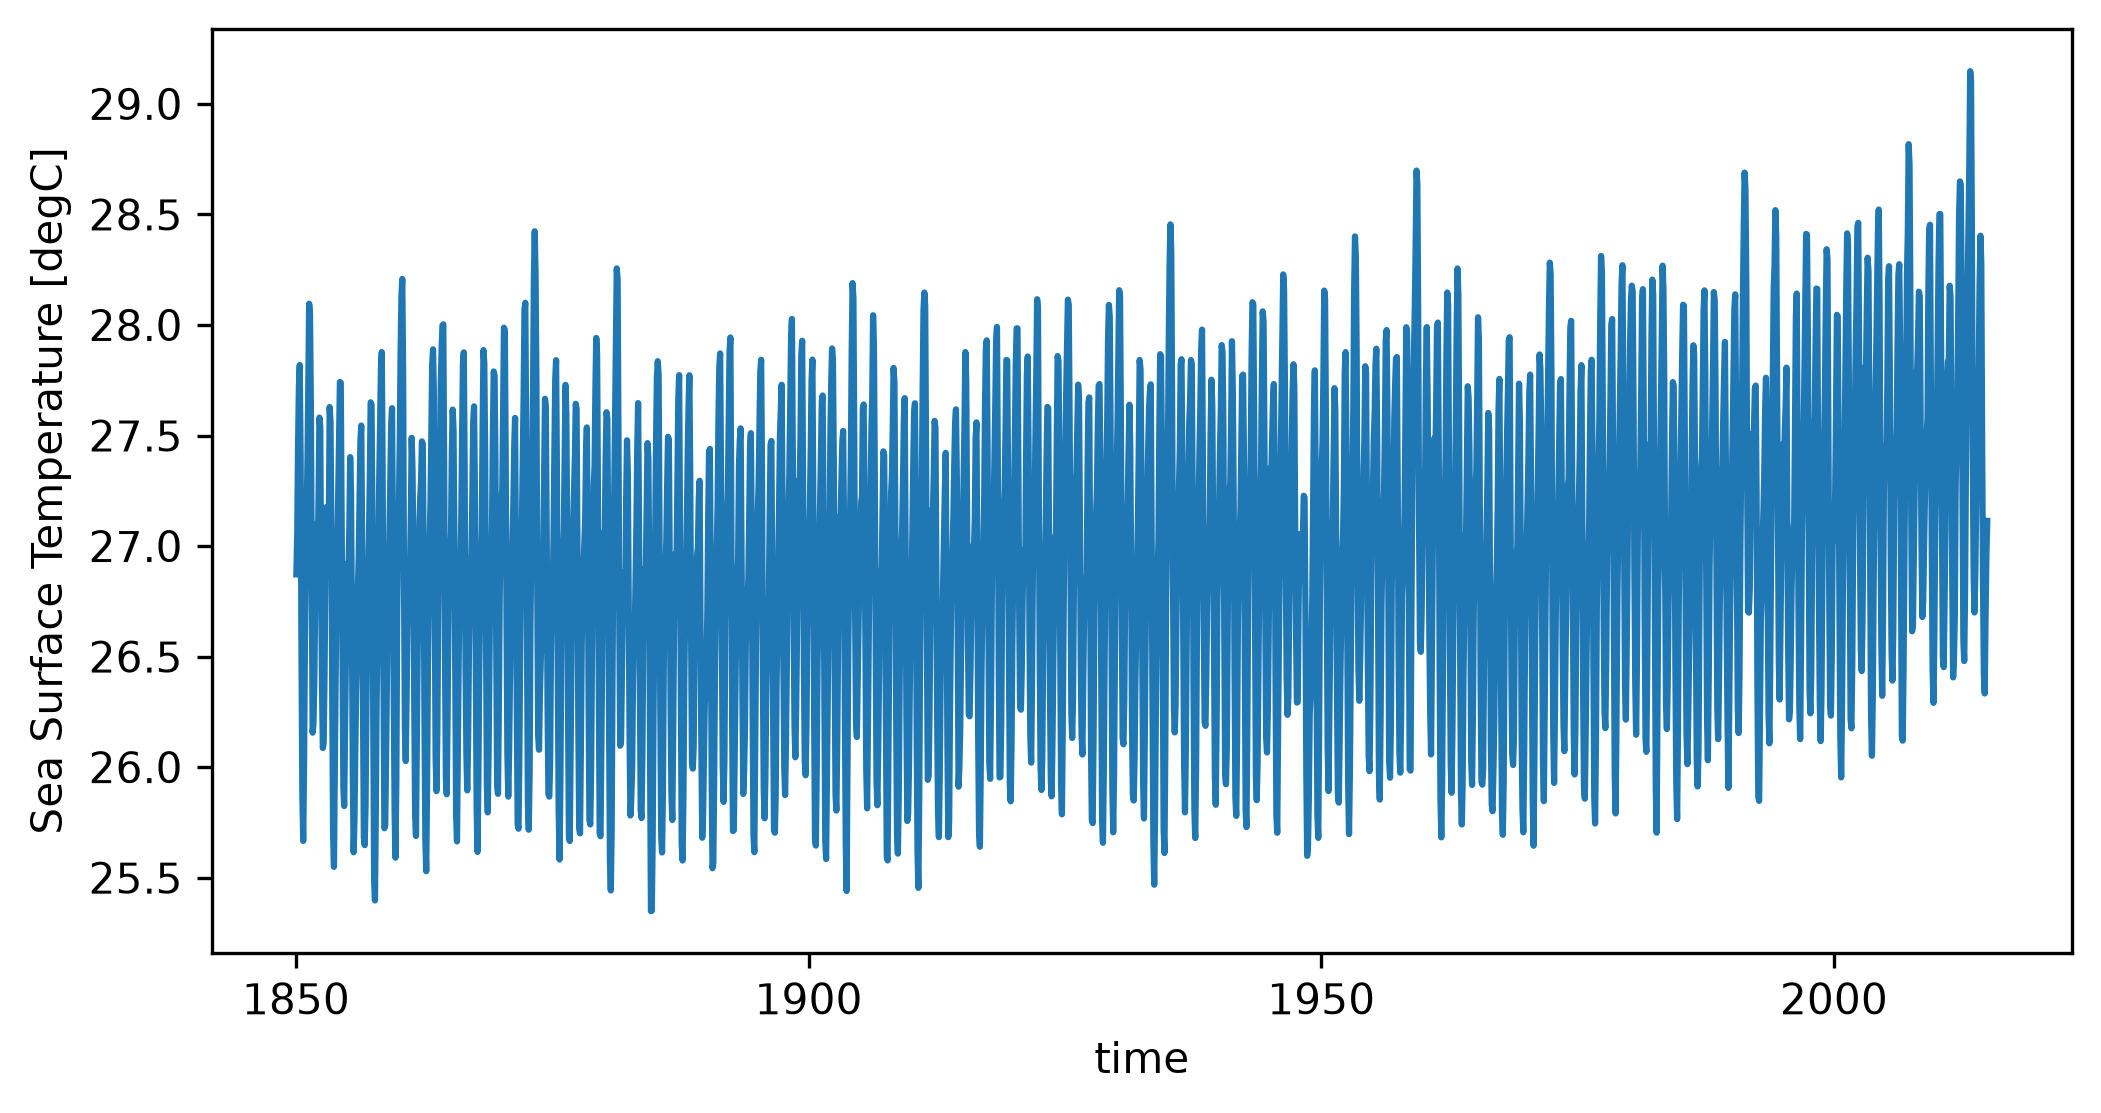

In [113]:
# Blank canvas to plot on
fig = plt.figure(figsize=(8,4), dpi=300) # dpi controls the image resolution

# Plot the data
ts.plot()

# OPTIONAL: save the figure on your computer
# fig.savefig("FILE_NAME.png")

plt.show()

### Creating the plot more manually, instead of automatically with Xarray. Allows for more customization

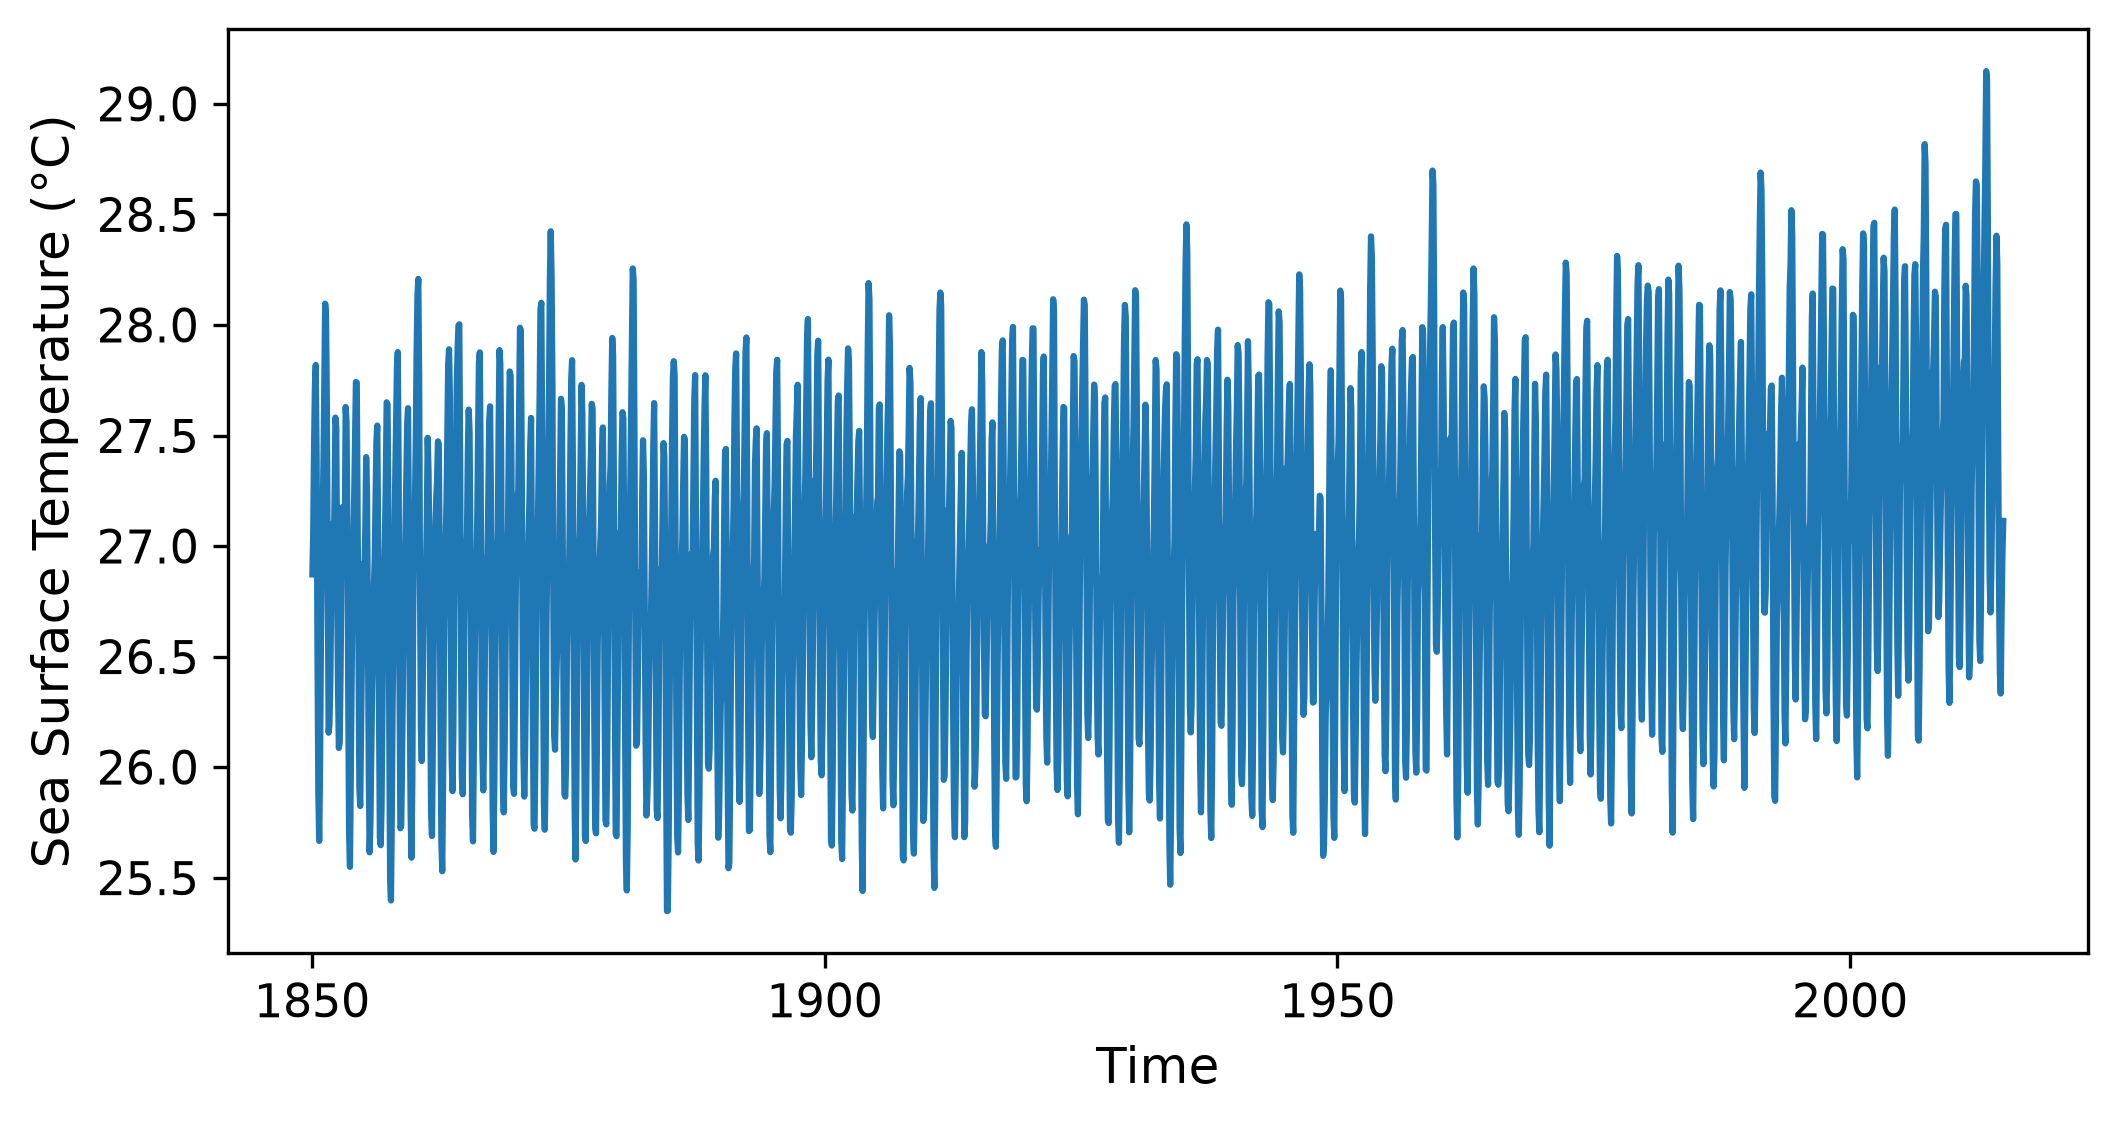

In [136]:
# Blank canvas to plot on
fig = plt.figure(figsize=(8,4), dpi=300) # dpi controls the image resolution

# Plot the data
plt.plot(ts.time, ts)

# Customize the axes and labels
plt.xlabel('Time', fontsize=12)
plt.ylabel('Sea Surface Temperature (°C)', fontsize=12)
plt.tick_params(labelsize=11)

# OPTIONAL: save the figure on your computer
# fig.savefig("FILE_NAME.png")

plt.show()

## Take an anomaly by removing the monthly climatology

In [115]:
# Compute the anomaly
ts_anom = ts.groupby('time.month') - ts.groupby('time.month').mean('time')

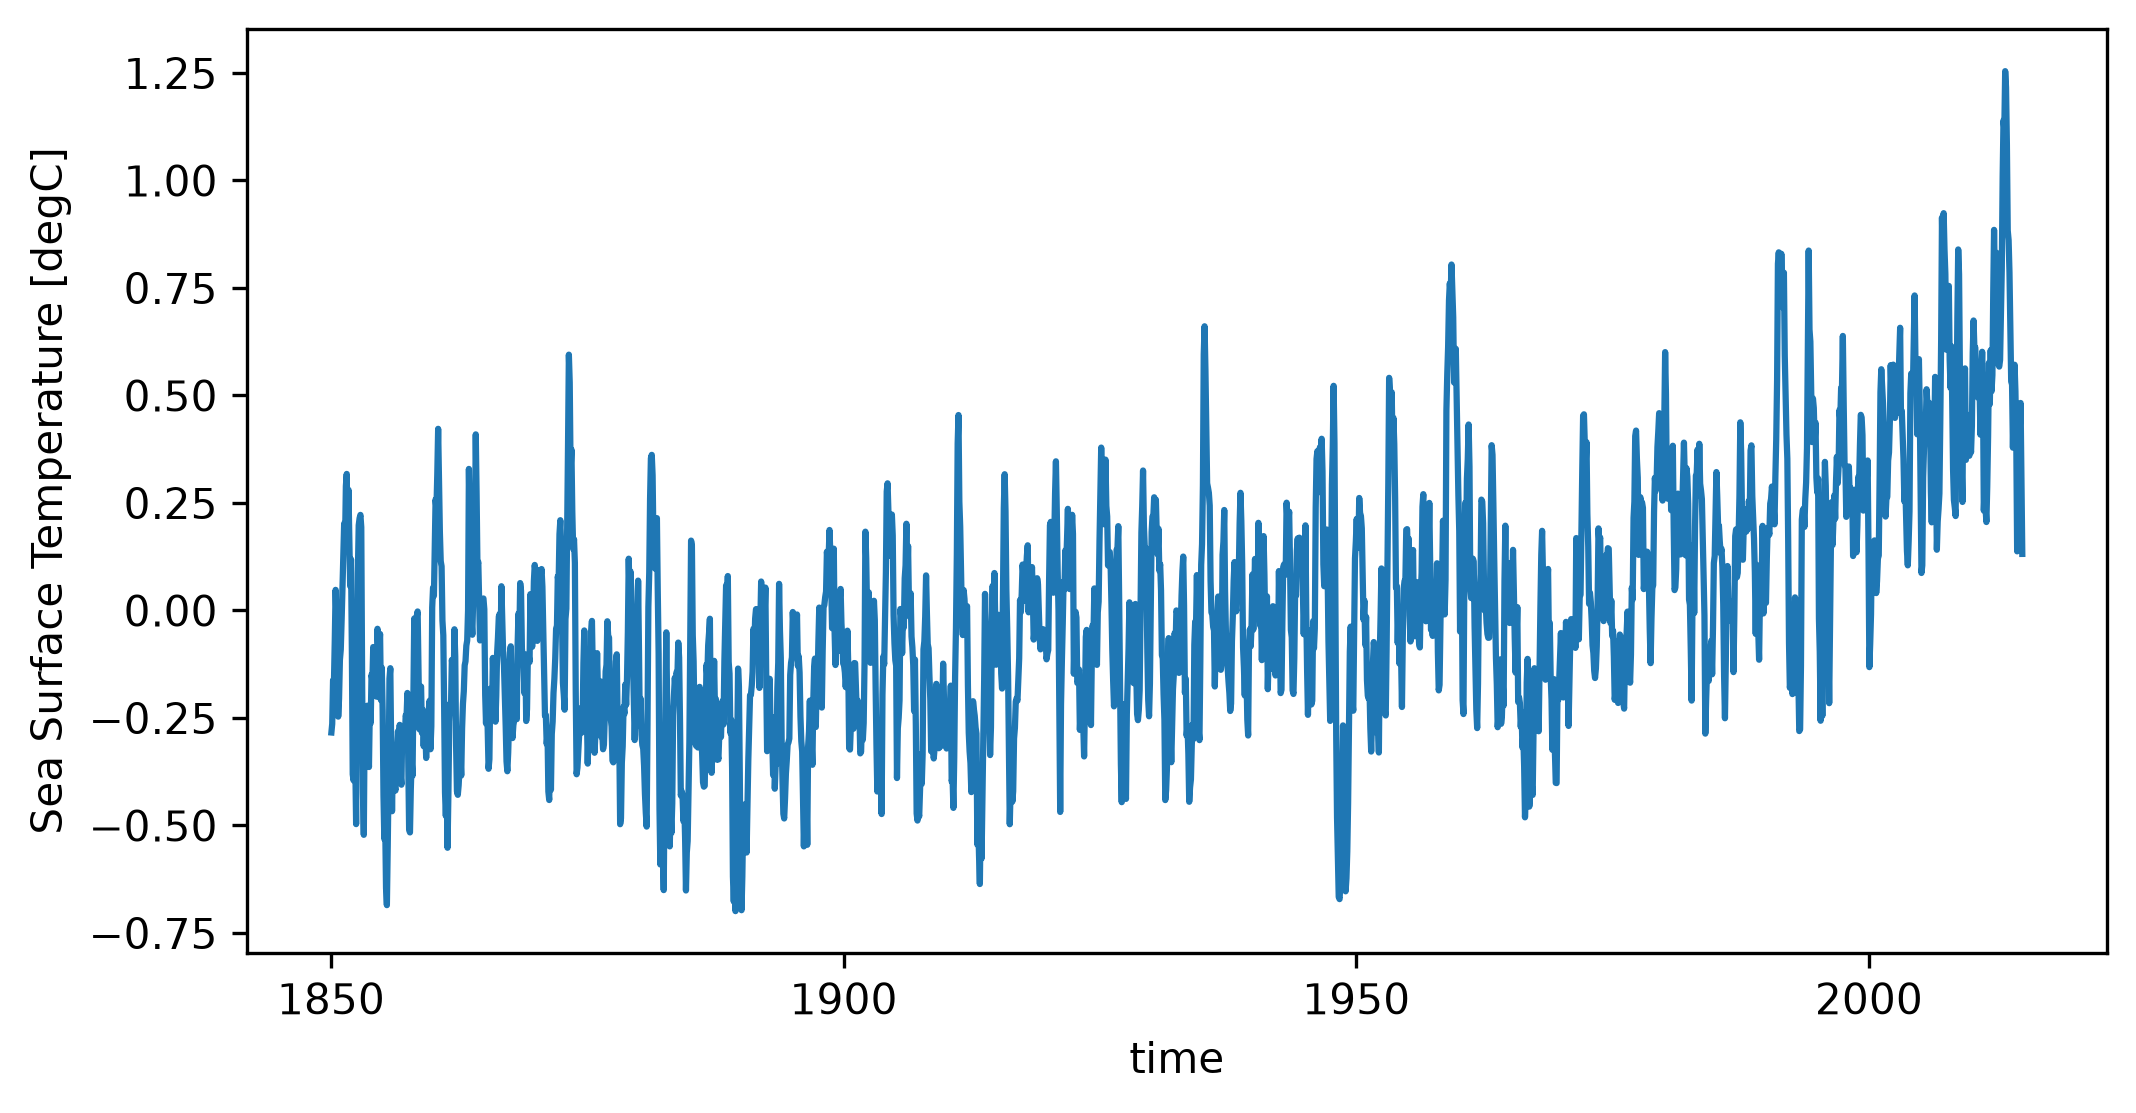

In [116]:
# Blank canvas to plot on
fig = plt.figure(figsize=(8,4), dpi=300) # dpi controls the image resolution

# Plot the data
ts_anom.plot()

# OPTIONAL: save the figure on your computer
# fig.savefig("FILE_NAME.png")

plt.show()

## Making multi-panel plots

In [117]:
# Get global mean temperature anomaly
ts_global = data.mean(dim=('lat','lon'))
ts_global = ts_global.groupby('time.month') - ts_global.groupby('time.month').mean('time')

### Timeseries

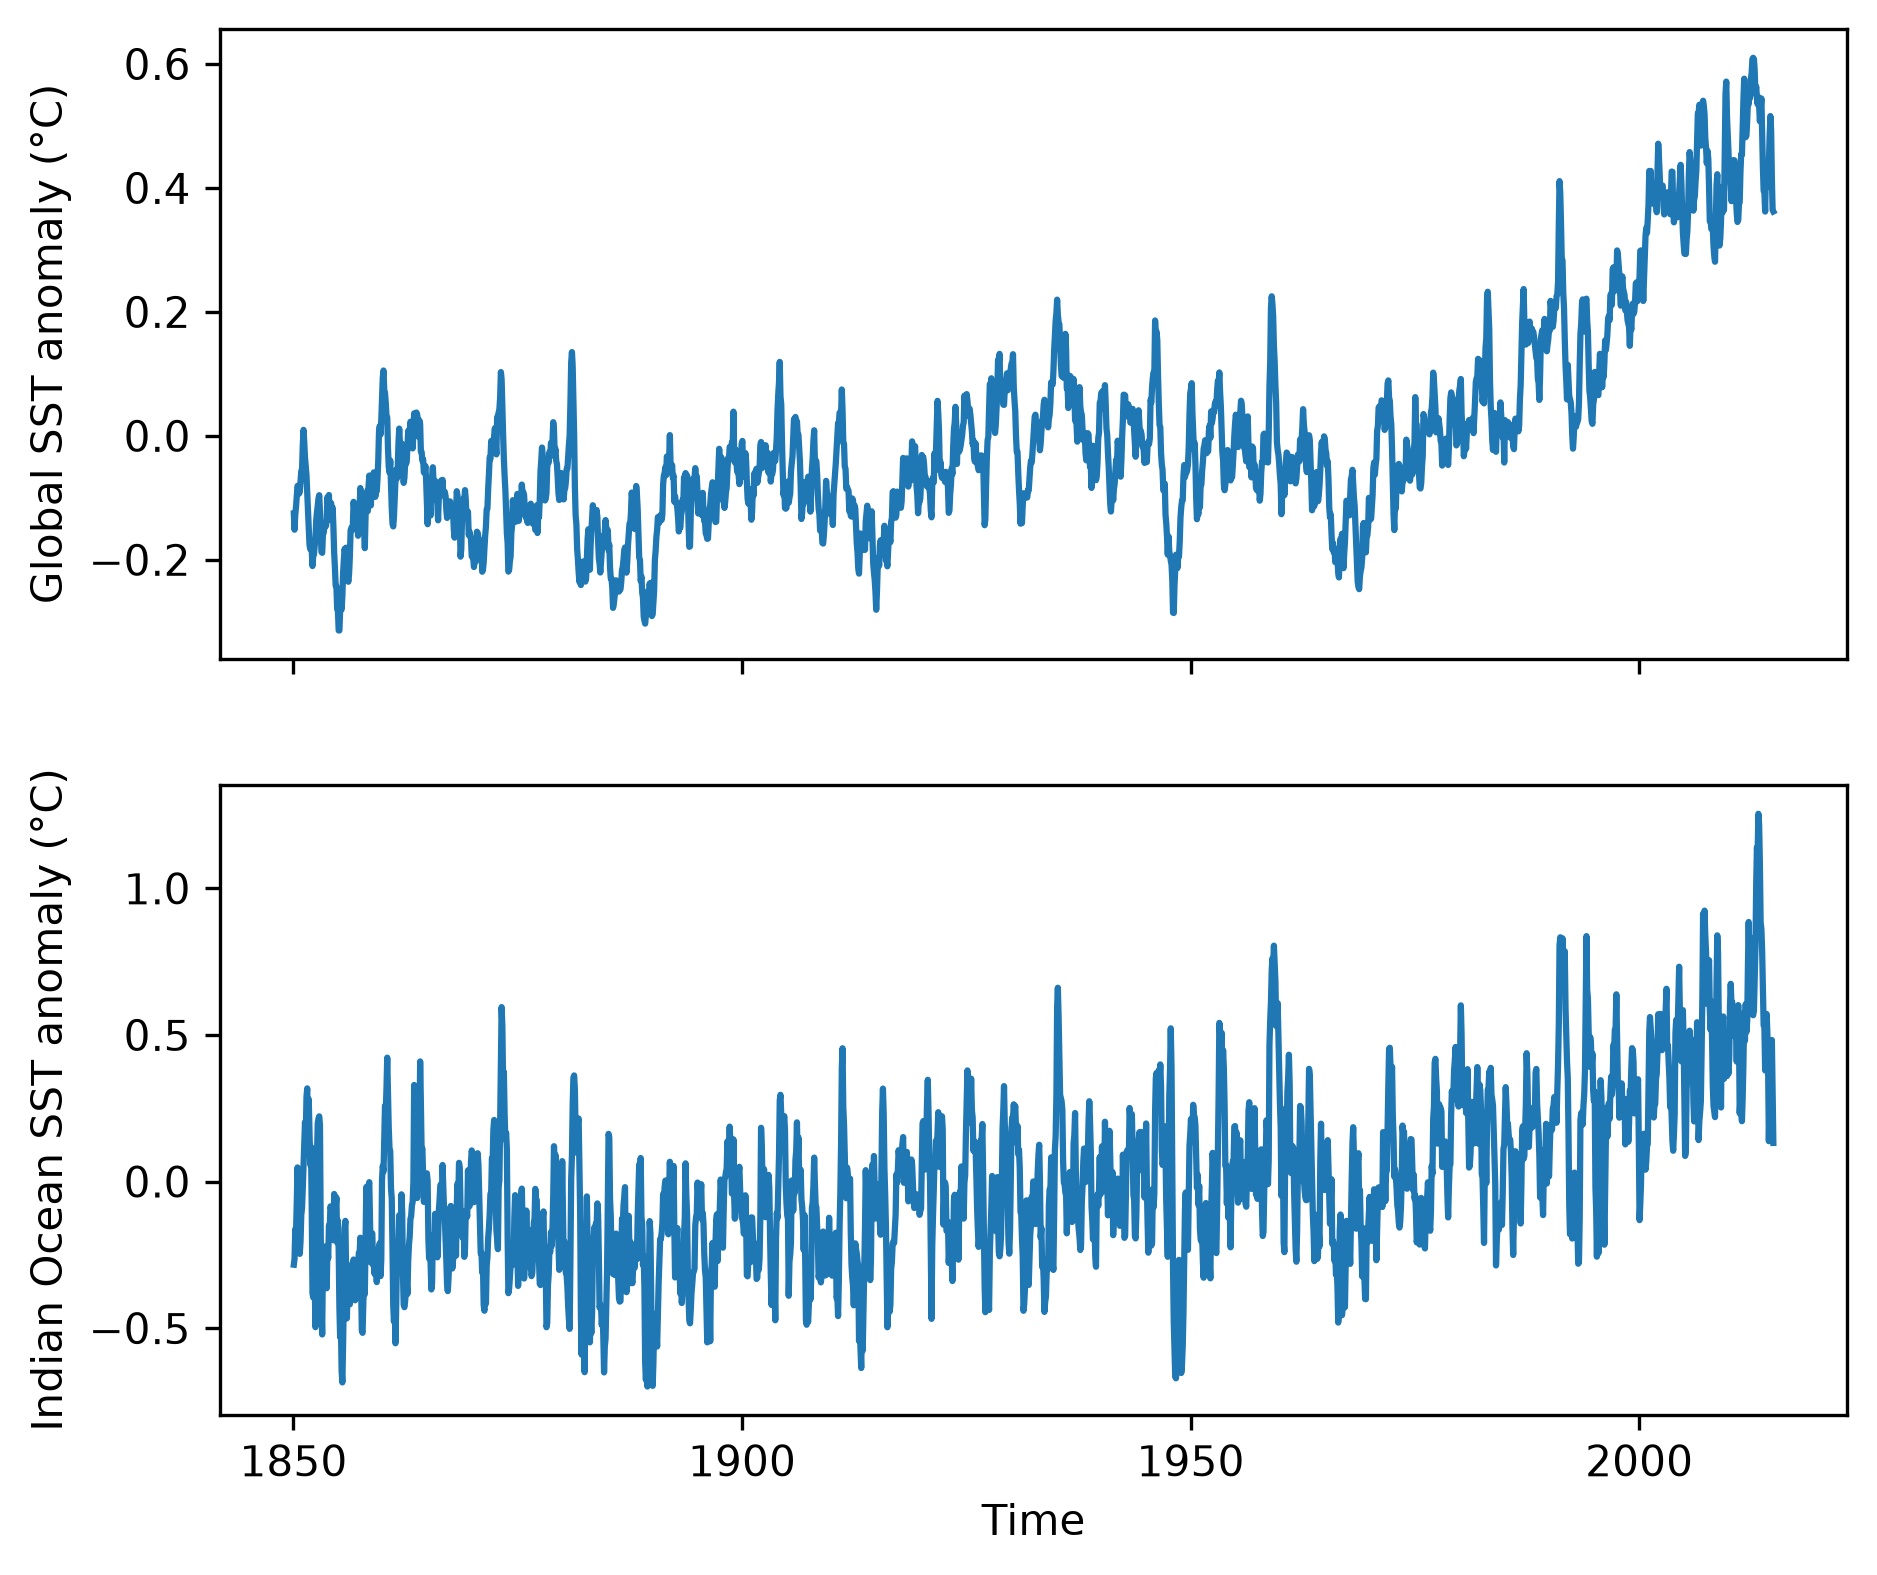

In [118]:
# Blank subplot canvas to plot on.
# If you want the subplots to have the same x and/or y axis, can set sharex, sharey = True. They are automatically set to False.
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(7,6), sharex=True, dpi=300) 

# Plot the data
ts_global.plot(ax=ax[0])
ts_anom.plot(ax=ax[1])

# Axis labels
ax[0].set_xlabel(None)
ax[1].set_xlabel('Time')
ax[0].set_ylabel('Global SST anomaly (°C)')
ax[1].set_ylabel('Indian Ocean SST anomaly (°C)')

# OPTIONAL: save the figure on your computer
# fig.savefig("FILE_NAME.png")

plt.show()

### Spatial Subplots

For more info on multi-panel spatial plots, see this site: https://kpegion.github.io/Pangeo-at-AOES/examples/multi-panel-cartopy.html

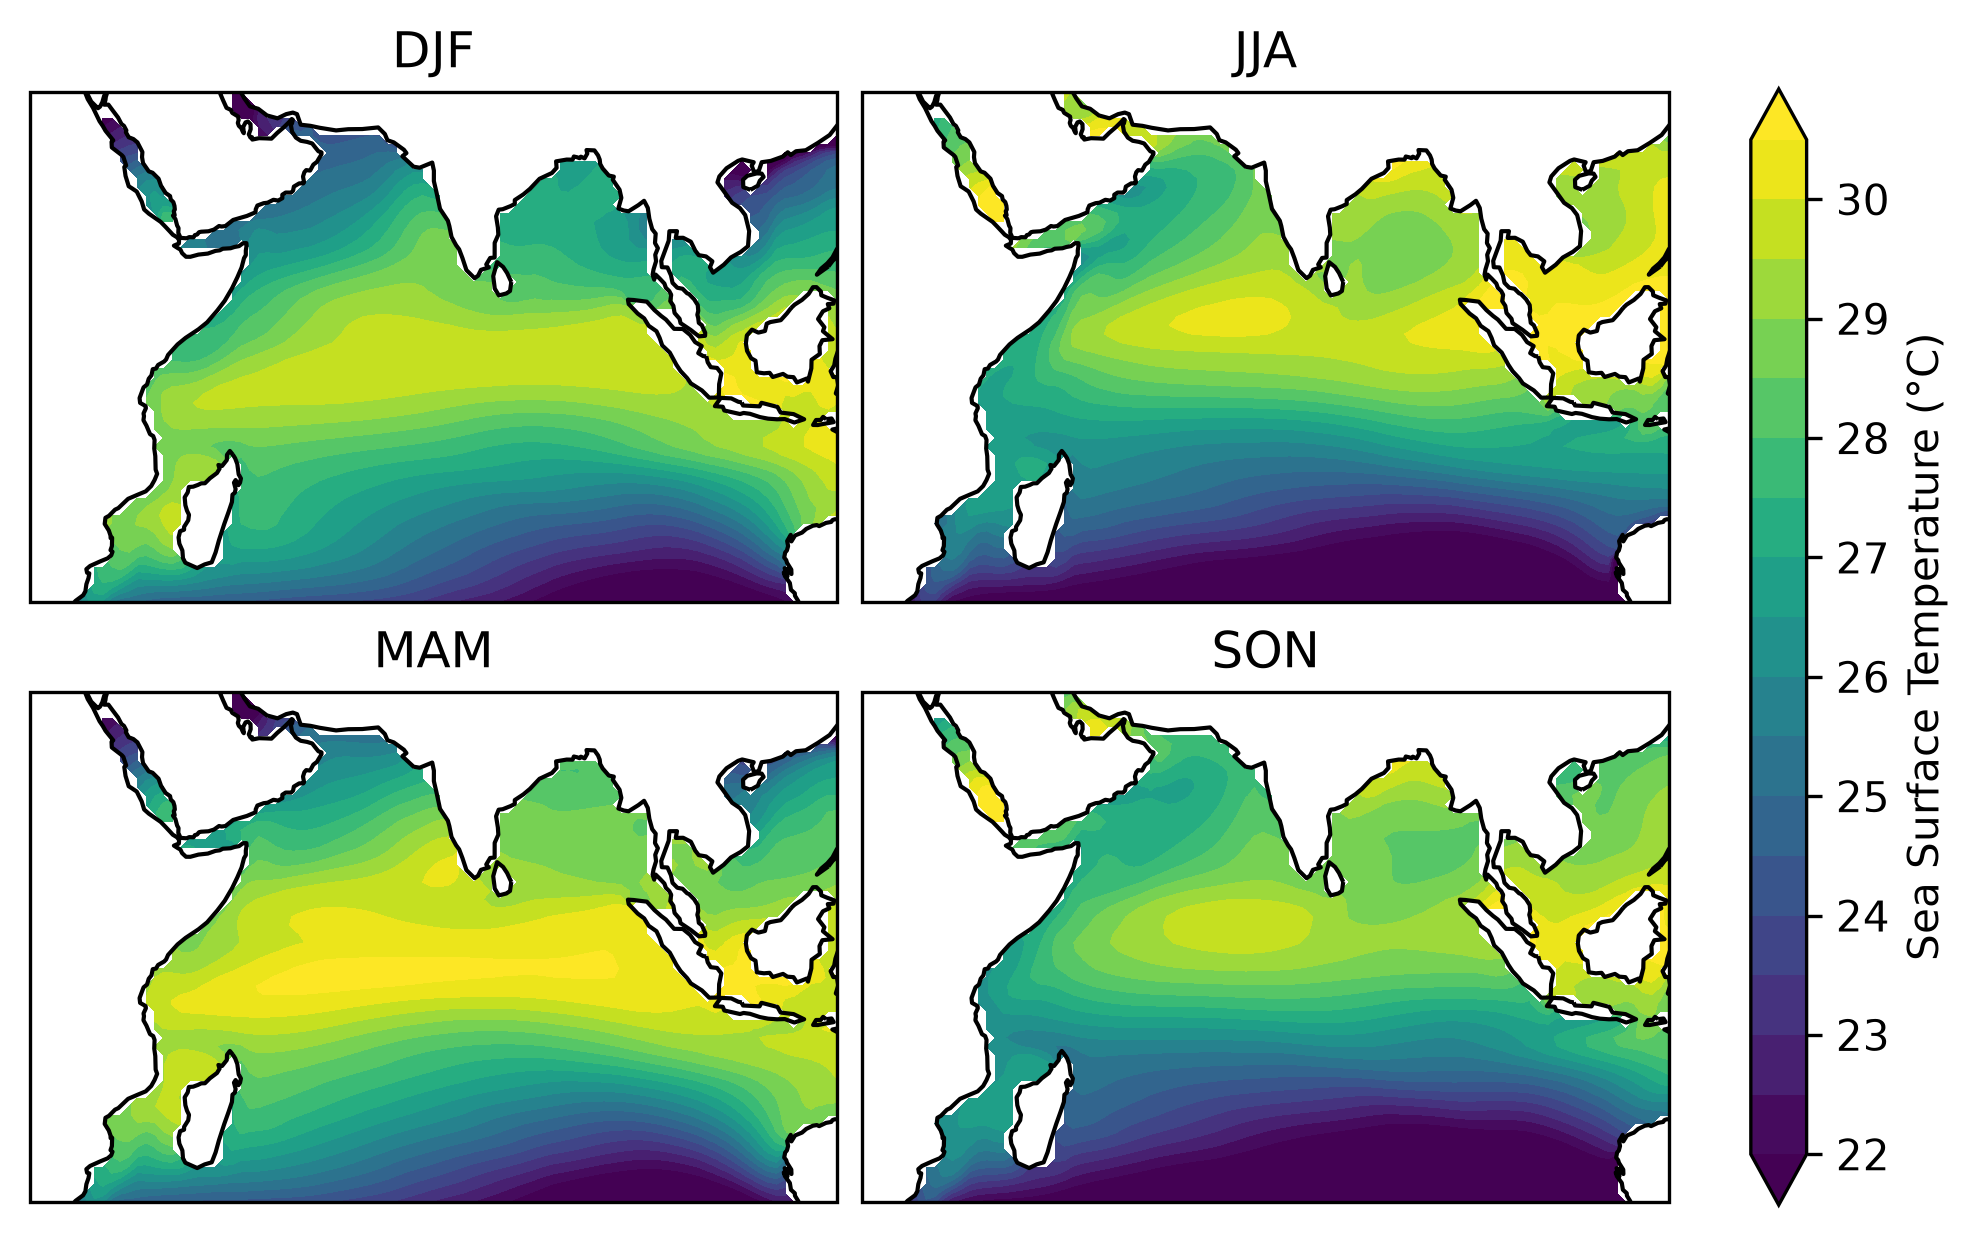

In [124]:
# Set up the subplots figure. For mapping, include: subplot_kw={'projection': ccrs.PlateCarree()}
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(6.5,4), dpi=300, layout='constrained', subplot_kw={'projection': ccrs.PlateCarree()})

ax_1d = ax.flatten()

# This for loop structure with "enumerate" is very useful.
# For each step in the for loop, it gives you both the item (season) and its corresponding index (idx)
for idx, season in enumerate(data_subset.groupby('time.season')):

    # Xarray's groupby('time.season') feature gives you both the season name and the data for that season
    season_name = season[0]
    season_data = season[1]
    
    # Plot the data
    pc = ax_1d[idx].contourf(season_data.lon, season_data.lat, season_data.mean('time'), levels = np.arange(22, 31, 0.5), extend='both') 
    # Note: important that all the subplots have the same levels, so they can share a colorbar

    ax_1d[idx].set_title(season_name)

# Draw the coastlines
for axis in ax_1d:
    axis.coastlines()

# Make colorbar
cbar = fig.colorbar(pc, ax=ax, orientation='vertical', label='Sea Surface Temperature (°C)', extend='both')

# OPTIONAL: save the figure on your computer
# fig.savefig("FILE_NAME.png")

plt.show()

## Other Types of Plots

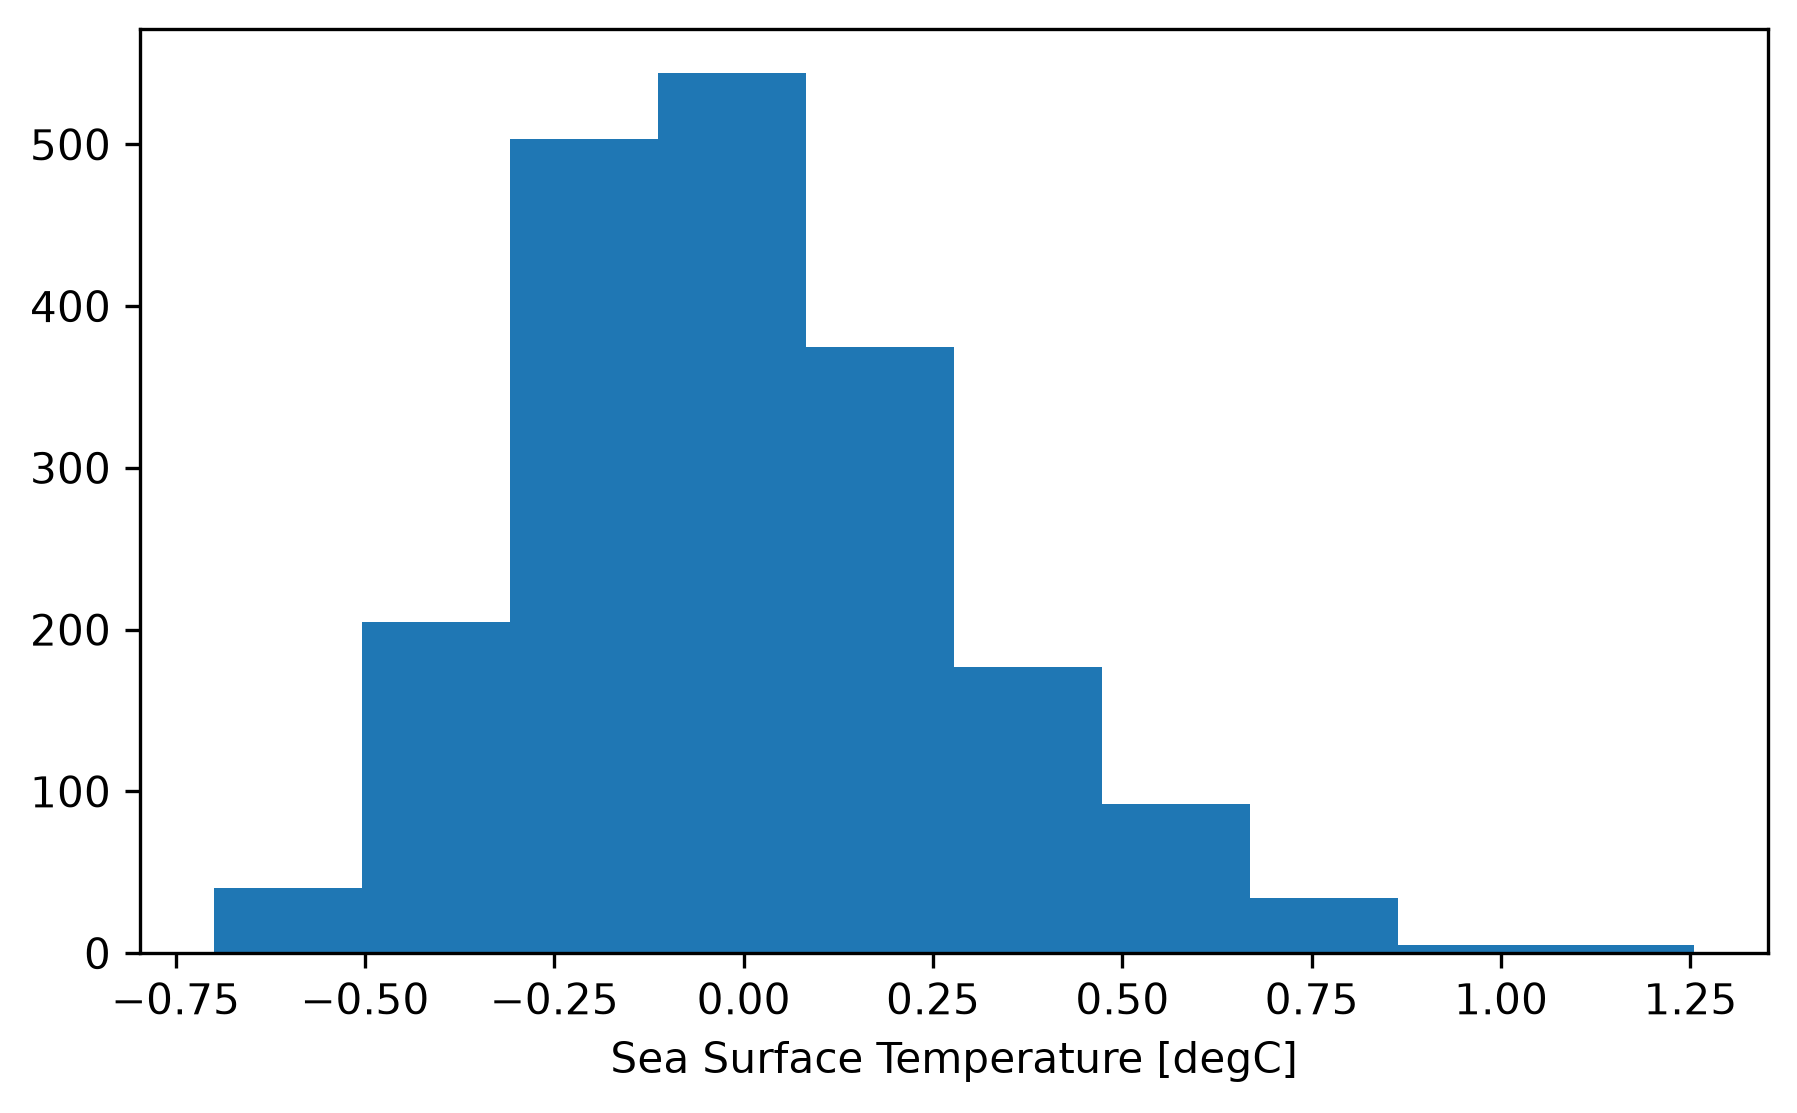

In [71]:
# Histogram

# Blank canvas to plot on
fig = plt.figure(figsize=(7,4), dpi=300) # dpi controls the image resolution

# Plot the data
ts_anom.plot.hist()

# OPTIONAL: save the figure on your computer
# fig.savefig("FILE_NAME.png")

plt.show()